In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

from itertools import product
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics

import warnings
warnings.filterwarnings('ignore')

/Users/oksjjj/coding/skada/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
plt.rcParams['figure.figsize'] = (10, 7.5)
plt.rcParams['axes.grid'] = False

## 19.7 Exercises
### 19.7.1 Forecast the number of air passengers with Prophet

In [3]:
df = pd.read_csv('../data/air-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


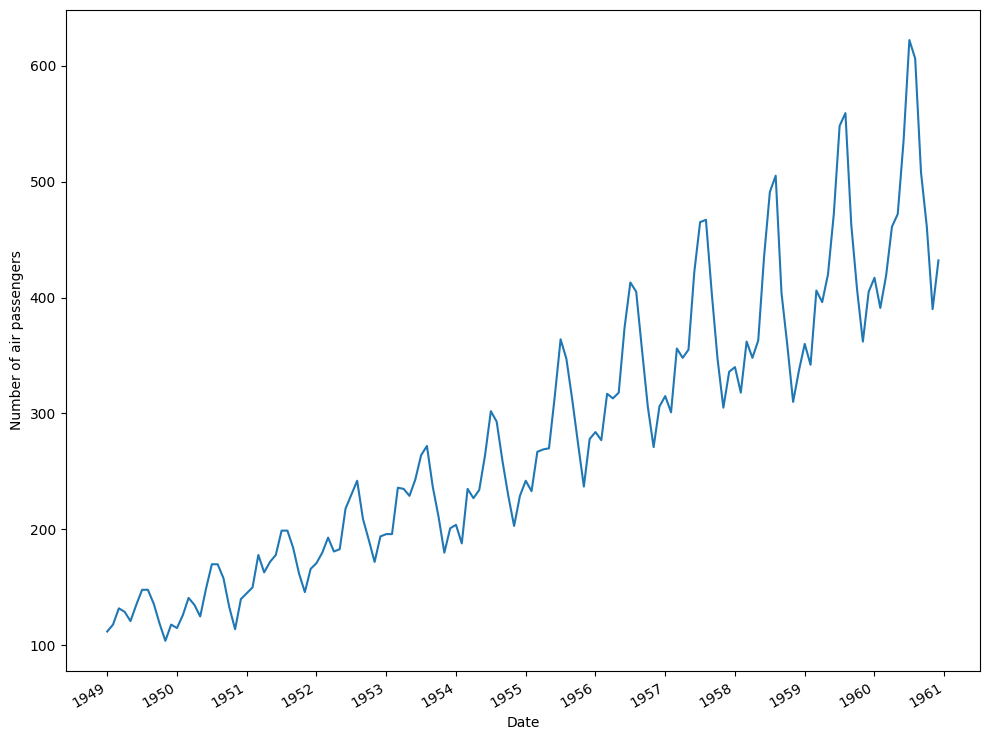

In [4]:
fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()

In [5]:
df.columns = ['ds', 'y']
df.head()

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [6]:
from pandas.tseries.offsets import MonthEnd

df['ds'] = pd.to_datetime(df['ds']) + MonthEnd(1)

df.head()

,ds,y
0,1949-01-31,112
1,1949-02-28,118
2,1949-03-31,132
3,1949-04-30,129
4,1949-05-31,121


In [7]:
train = df[:-12]
test = df[-12:]

In [8]:
train.tail()

,ds,y
127,1959-08-31,559
128,1959-09-30,463
129,1959-10-31,407
130,1959-11-30,362
131,1959-12-31,405


In [9]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

mses = []

cutoffs = pd.date_range(start='1953-01-31', end=train['ds'].max() - pd.Timedelta('365 days'), freq='12ME')

for param in params:
    m = Prophet(**param, seasonality_mode='multiplicative')
    m.add_country_holidays(country_name='US')
    m.fit(train)
    
    df_cv = cross_validation(model=m, horizon='365 days', cutoffs=cutoffs)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mses.append(df_p['mse'].values[0])
    
tuning_results = pd.DataFrame(params)
tuning_results['mse'] = mses

05:31:59 - cmdstanpy - INFO - Chain [1] start processing
05:31:59 - cmdstanpy - INFO - Chain [1] done processing
05:31:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
05:31:59 - cmdstanpy - INFO - Chain [1] start processing
05:31:59 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/6 [00:00<?, ?it/s]05:31:59 - cmdstanpy - INFO - Chain [1] start processing
05:32:00 - cmdstanpy - INFO - Chain [1] done processing
 17%|█▋        | 1/6 [00:00<00:00,  5.74it/s]05:32:00 - cmdstanpy - INFO - Chain [1] start processing
05:32:00 - cmdstanpy - INFO - Chain [1] done processing
 33%|███▎      | 2/6 [00:00<00:00,  7.49it/s]05:32:00 - cmdstanpy - INFO - Chain [1] start processing
05:32:00 - cmdstanpy - INFO - Chain [1] done processing
 50%|█████     | 3/6 [00:00<00:00,  6.55it/s]05:32:00 - cmdstanpy - INFO - Chain [1] start processing
05:32:00 - cmdstanpy - INFO - Chain [1] done processing
 67%|████

In [10]:
best_params = params[np.argmin(mses)]
print(best_params)

{'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 0.1}


In [11]:
m = Prophet(**best_params, seasonality_mode='multiplicative')
m.add_country_holidays(country_name='US')
m.fit(train)

05:32:36 - cmdstanpy - INFO - Chain [1] start processing
05:32:36 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
future = m.make_future_dataframe(periods=12, freq='ME')

In [13]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

,ds,yhat,yhat_lower,yhat_upper
132,1960-01-31,404.557872,394.327481,415.163770
133,1960-02-29,390.694919,380.002017,401.862993
134,1960-03-31,449.232027,438.204342,461.425810
135,1960-04-30,437.447785,426.016446,447.997966
136,1960-05-31,442.690403,431.204272,453.485721
137,1960-06-30,518.053413,505.685627,529.436770
138,1960-07-31,573.342707,559.899183,586.855265
139,1960-08-31,577.455053,562.869822,591.161376
140,1960-09-30,498.543655,483.815390,512.301446
141,1960-10-31,434.133503,418.835850,448.474316


In [14]:
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]
test.head()

,ds,y,yhat,yhat_lower,yhat_upper
132,1960-01-31,417,404.557872,394.327481,415.163770
133,1960-02-29,391,390.694919,380.002017,401.862993
134,1960-03-31,419,449.232027,438.204342,461.425810
135,1960-04-30,461,437.447785,426.016446,447.997966
136,1960-05-31,472,442.690403,431.204272,453.485721


In [15]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [16]:
mape_prophet = mape(test['y'], test['yhat'])

print(mape_prophet)

4.223136943277672


Recall that we obtained a MAPE of 2.85% using a SARIMA model in chapter 8. Therefore, Prophet does not outperform the SARIMA model in this case, since it achieves a MAPE of 4.28%.

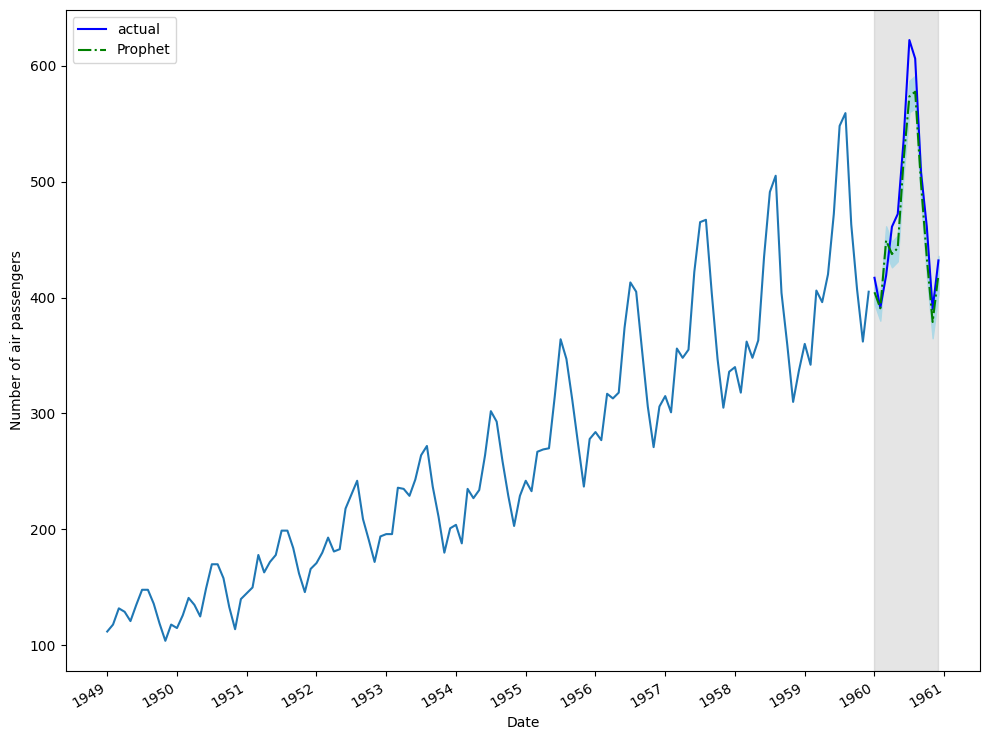

In [17]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='actual')
ax.plot(test['yhat'], 'g-.', label='Prophet')

ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')
ax.axvspan(132, 143, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')

fig.autofmt_xdate()
plt.tight_layout()

### 19.7.3 Forecast the monthly volume of anti-diabetic drug prescriptions 

In [18]:
df = pd.read_csv('../data/AusAntidiabeticDrug.csv')
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1991-07-01,3.526591
1,1991-08-01,3.180891
2,1991-09-01,3.252221
3,1991-10-01,3.611003
4,1991-11-01,3.565869


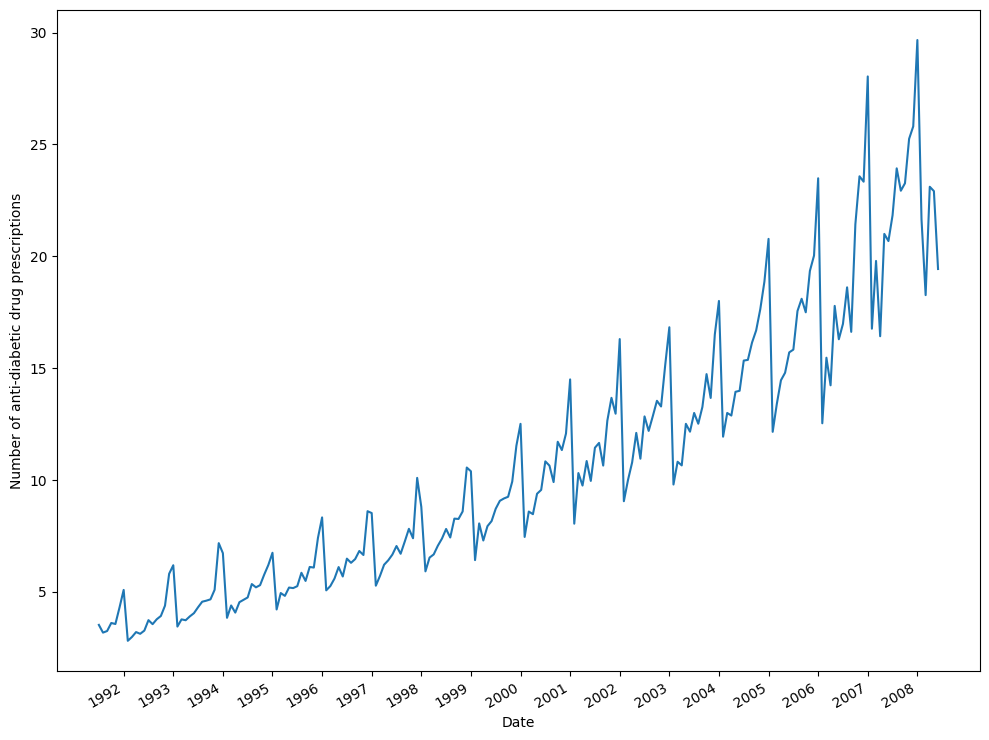

In [19]:
fig, ax = plt.subplots()

ax.plot(df['y'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))

fig.autofmt_xdate()
plt.tight_layout()

In [20]:
train = df[:-36]
test = df[-36:]

In [21]:
train.tail()

,ds,y
163,2005-02-01,12.154552
164,2005-03-01,13.402392
165,2005-04-01,14.459239
166,2005-05-01,14.795102
167,2005-06-01,15.705248


In [22]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1, 0.5],
    'seasonality_prior_scale': [0.01, 0.1, 1.0, 10.0]
}

params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

mses = []

cutoffs = pd.date_range(start='1995-01-01', end=train['ds'].max() - pd.Timedelta('365 days'), freq='12MS')

for param in params:
    m = Prophet(**param, seasonality_mode='multiplicative')
    m.fit(train)
    
    df_cv = cross_validation(model=m, horizon='365 days', cutoffs=cutoffs)
    df_p = performance_metrics(df_cv, rolling_window=1)
    mses.append(df_p['mse'].values[0])
    
tuning_results = pd.DataFrame(params)
tuning_results['mse'] = mses

05:32:51 - cmdstanpy - INFO - Chain [1] start processing
05:32:51 - cmdstanpy - INFO - Chain [1] done processing
  0%|          | 0/10 [00:00<?, ?it/s]05:32:51 - cmdstanpy - INFO - Chain [1] start processing
05:32:51 - cmdstanpy - INFO - Chain [1] done processing
05:32:51 - cmdstanpy - INFO - Chain [1] start processing
05:32:53 - cmdstanpy - INFO - Chain [1] done processing
 20%|██        | 2/10 [00:01<00:05,  1.47it/s]05:32:53 - cmdstanpy - INFO - Chain [1] start processing
05:32:53 - cmdstanpy - INFO - Chain [1] done processing
 30%|███       | 3/10 [00:01<00:03,  2.00it/s]05:32:53 - cmdstanpy - INFO - Chain [1] start processing
05:32:53 - cmdstanpy - INFO - Chain [1] done processing
 40%|████      | 4/10 [00:01<00:02,  2.45it/s]05:32:53 - cmdstanpy - INFO - Chain [1] start processing
05:32:53 - cmdstanpy - INFO - Chain [1] done processing
05:32:53 - cmdstanpy - INFO - Chain [1] start processing
05:32:53 - cmdstanpy - INFO - Chain [1] done processing
05:32:53 - cmdstanpy - ERROR - Ch

In [23]:
best_params = params[np.argmin(mses)]
print(best_params)

{'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0}


In [24]:
m = Prophet(**best_params, seasonality_mode='multiplicative')
m.fit(train)

05:33:15 - cmdstanpy - INFO - Chain [1] start processing
05:33:15 - cmdstanpy - INFO - Chain [1] done processing


In [25]:
future = m.make_future_dataframe(periods=36, freq='MS')

In [26]:
forecast = m.predict(future)
test[['yhat', 'yhat_lower', 'yhat_upper']] = forecast[['yhat', 'yhat_lower', 'yhat_upper']]

test.head()

,ds,y,yhat,yhat_lower,yhat_upper
168,2005-07-01,15.829550,16.067262,15.412335,16.660953
169,2005-08-01,17.554701,15.869892,15.247667,16.485435
170,2005-09-01,18.100864,16.131291,15.537806,16.742213
171,2005-10-01,17.496668,17.366665,16.782284,17.985512
172,2005-11-01,19.347265,17.532020,16.963826,18.141283


In [27]:
mape_prophet = mape(test['y'], test['yhat'])

print(mape_prophet)

12.096456800154028


In chapter 11, we built a SARIMA model that achieved a MAPE of 7.9%. Using Prophet, we achieved a MAPE of 12.1%. Therefore, Prophet does not outperform SARIMA in this case.

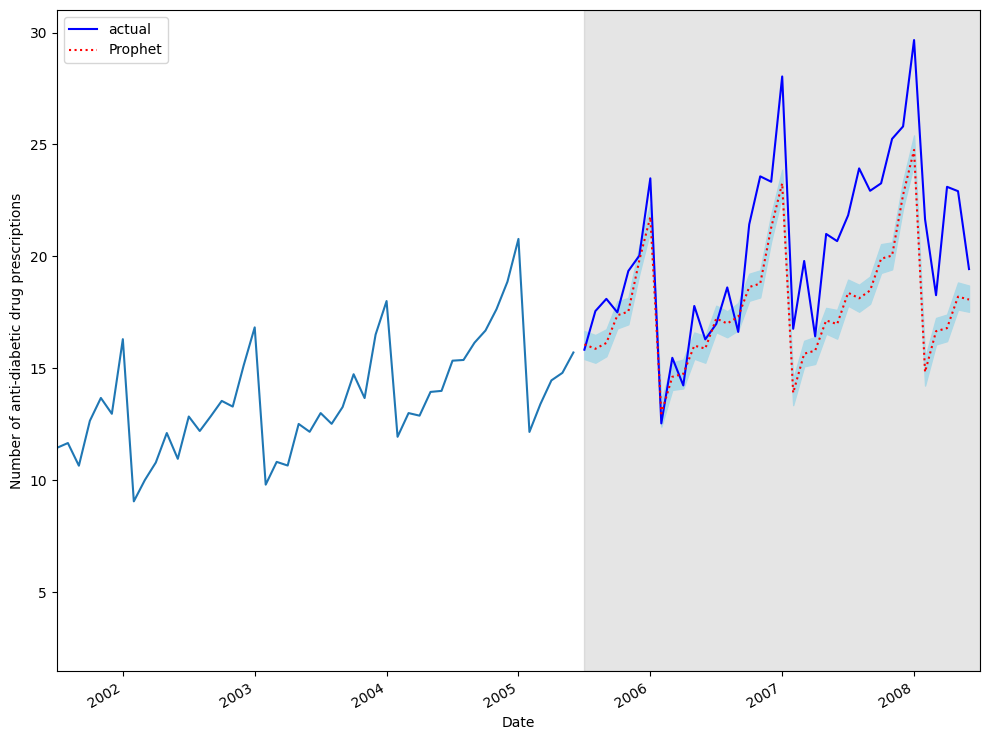

In [28]:
fig, ax = plt.subplots()

ax.plot(train['y'])
ax.plot(test['y'], 'b-', label='actual')
ax.plot(test['yhat'], 'r:', label='Prophet')

ax.set_xlabel('Date')
ax.set_ylabel('Number of anti-diabetic drug prescriptions')
ax.axvspan(168, 204, color='#808080', alpha=0.2)

ax.legend(loc=2)

plt.xticks(np.arange(6, 203, 12), np.arange(1992, 2009, 1))
plt.fill_between(x=test.index, y1=test['yhat_lower'], y2=test['yhat_upper'], color='lightblue')
plt.xlim(120, 204)

fig.autofmt_xdate()
plt.tight_layout()